# 🌾 AI-Based Crop Yield Prediction System

## 📖 Introduction
This project predicts crop yield using machine learning techniques.

## 🎯 Objective
- Analyze agricultural data
- Apply ML models
- Compare performance

## 📊 Data Preprocessing
Cleaning, selecting, and merging datasets.

## 📈 Visualization
Analyzing relationships between variables.

## 🤖 Model Building
Using Linear Regression, Decision Tree, Random Forest.

## 📉 Results
Random Forest performed best.

## 🔮 Prediction System
User input-based yield prediction.

## 📌 Conclusion
Machine learning helps in better agricultural decisions.

“AI in Agriculture for Crop Yield Prediction”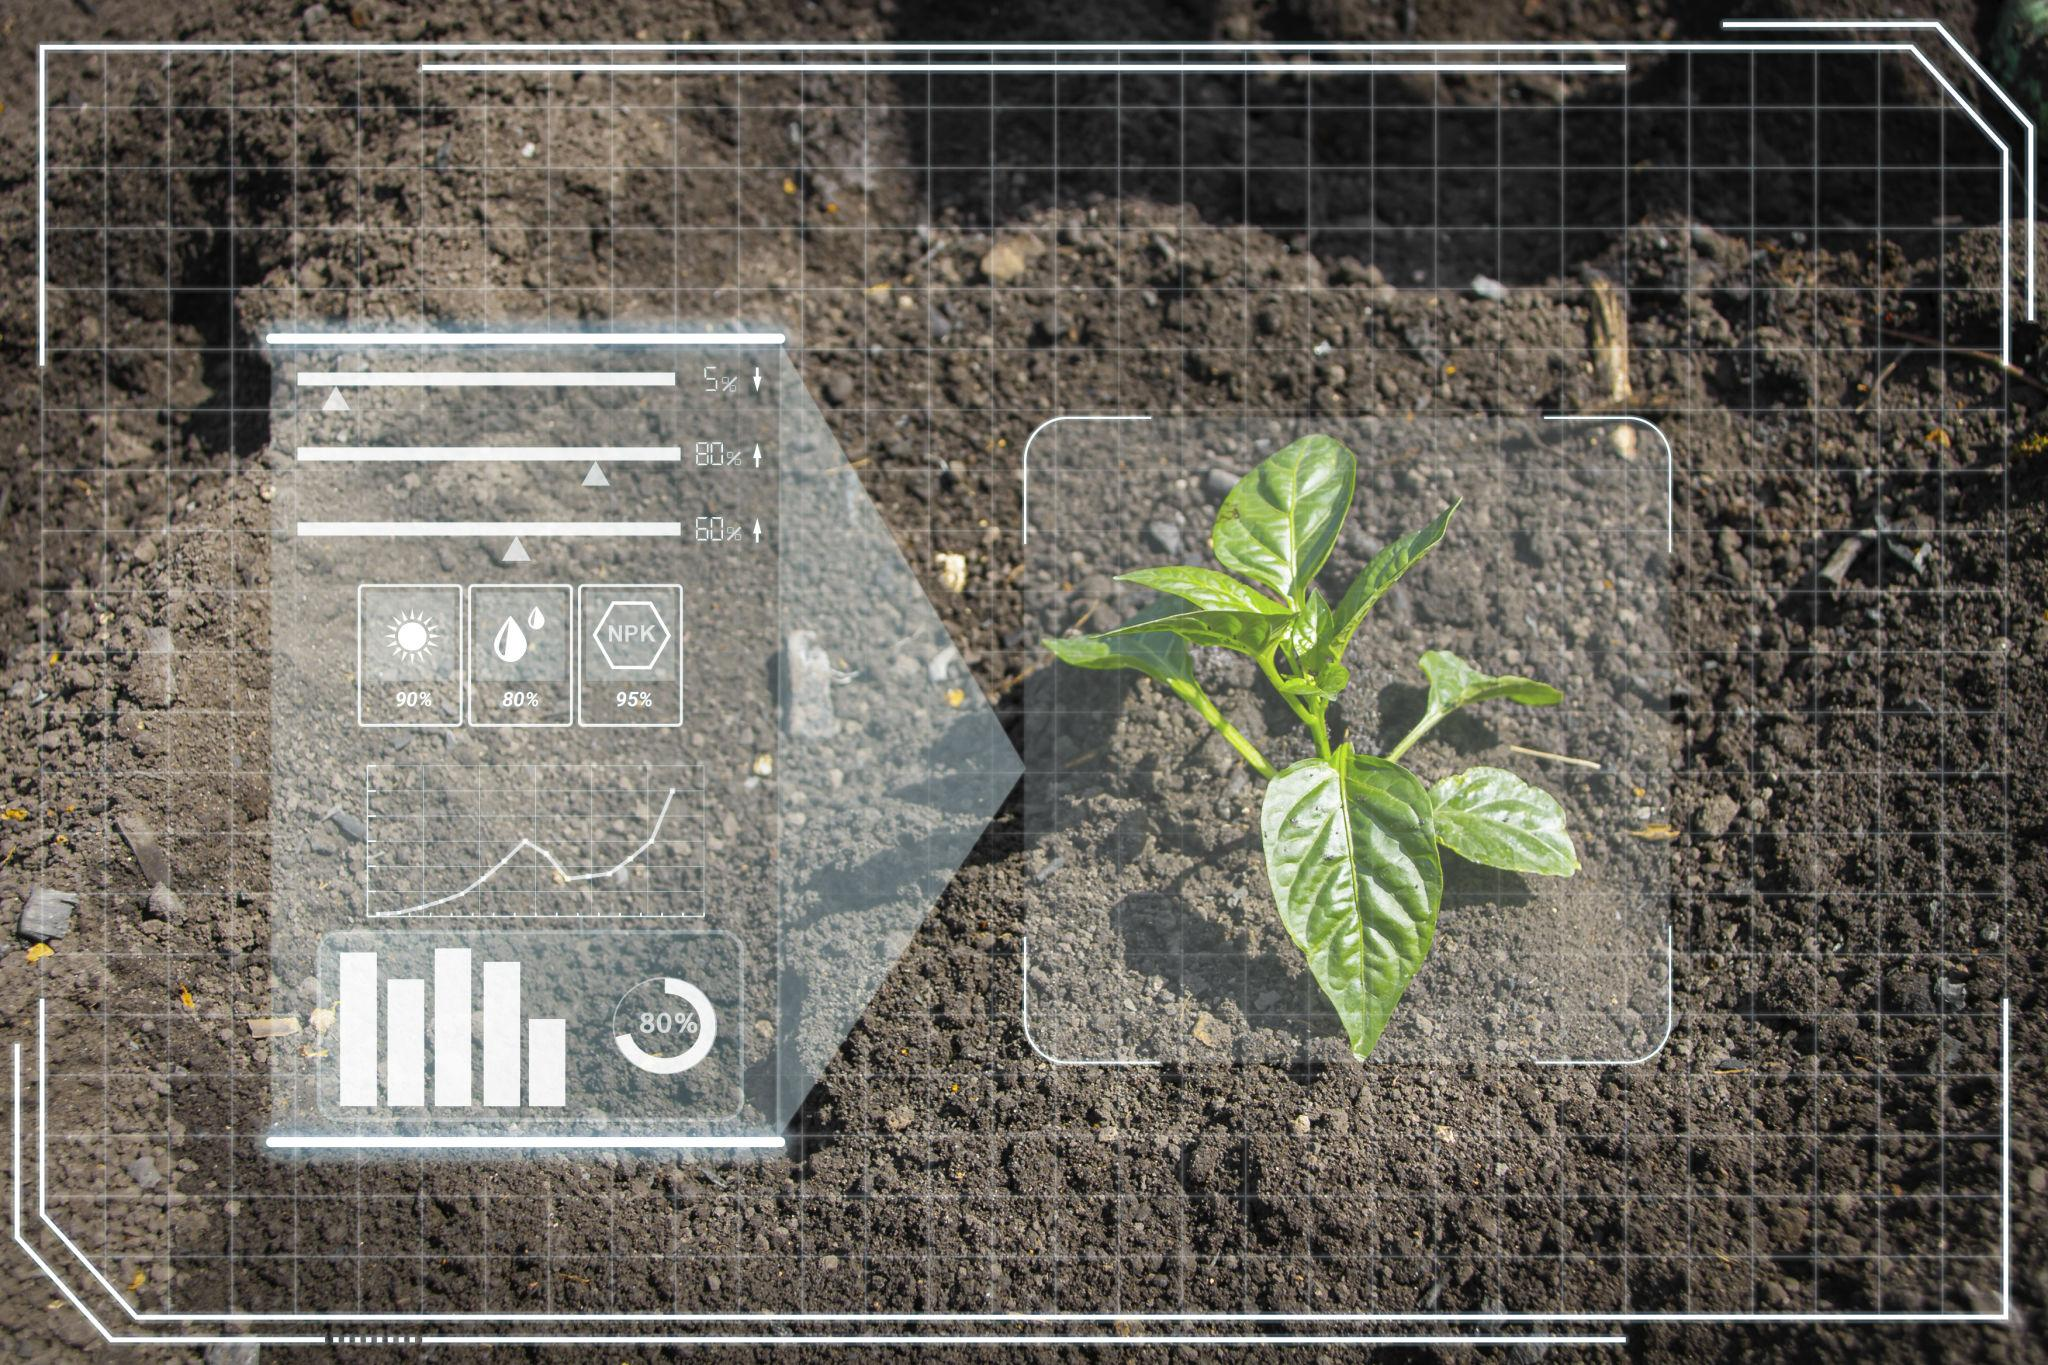

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# Load data
rain = pd.read_csv("rainfall.csv")
temp = pd.read_csv("temp.csv")
pest = pd.read_csv("pesticides.csv")
yield_df = pd.read_csv("yield.csv")

In [53]:
# ================== FIX COLUMN NAMES ==================
rain.columns = rain.columns.str.strip()
temp.columns = temp.columns.str.strip()
pest.columns = pest.columns.str.strip()
yield_df.columns = yield_df.columns.str.strip()

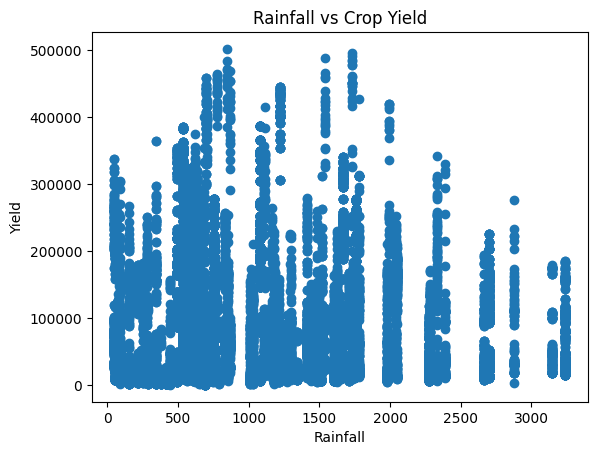

Linear Regression Accuracy: 0.021231344747230763
Random Forest Accuracy: -0.18894902363851807
Decision Tree Accuracy: -0.2594330632097539


In [54]:
# ================== SELECT & RENAME ==================

# Rainfall
rain = rain[['Area', 'Year', 'average_rain_fall_mm_per_year']]
rain.rename(columns={'average_rain_fall_mm_per_year': 'Rainfall'}, inplace=True)

# Temperature
temp.rename(columns={
    'year': 'Year',
    'country': 'Area',
    'avg_temp': 'Temperature'
}, inplace=True)
temp = temp[['Area', 'Year', 'Temperature']]

# Pesticides
pest = pest[['Area', 'Year', 'Value']]
pest.rename(columns={'Value': 'Pesticides'}, inplace=True)

# Yield
yield_df = yield_df[['Area', 'Year', 'Value']]
yield_df.rename(columns={'Value': 'Yield'}, inplace=True)

# ================== MERGE DATA ==================
data = pd.merge(rain, temp, on=['Area', 'Year'])
data = pd.merge(data, pest, on=['Area', 'Year'])
data = pd.merge(data, yield_df, on=['Area', 'Year'])

# ================== CLEAN DATA ==================
data['Rainfall'] = pd.to_numeric(data['Rainfall'], errors='coerce')
data = data.dropna()

# ================== VISUALIZATION ==================
plt.scatter(data['Rainfall'], data['Yield'])
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Rainfall vs Crop Yield")
plt.show()

# ================== MACHINE LEARNING ==================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X = data[['Rainfall', 'Temperature', 'Pesticides']]
y = data['Yield']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression Accuracy:", r2_score(y_test, lr_model.predict(X_test)))

# Random Forest
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", r2_score(y_test, y_pred))

# Decision Tree
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)
print("Decision Tree Accuracy:", r2_score(y_test, dt_model.predict(X_test)))


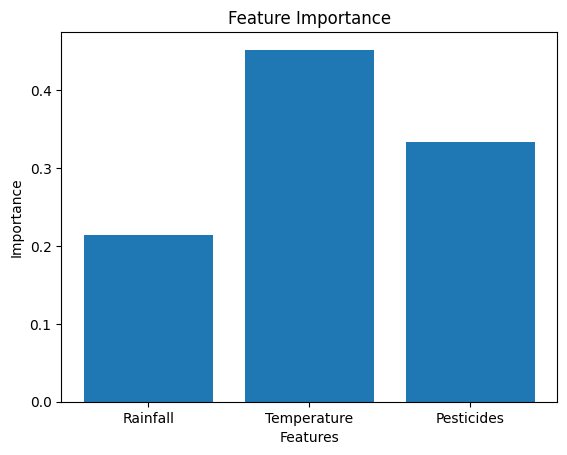

In [55]:
# ================== FEATURE IMPORTANCE ==================
importance = rf_model.feature_importances_
features = ['Rainfall', 'Temperature', 'Pesticides']

plt.bar(features, importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

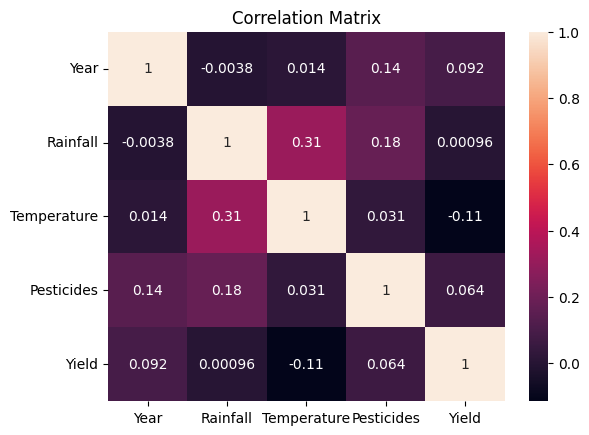

In [56]:
# ================== HEATMAP ==================
sns.heatmap(data[['Year','Rainfall','Temperature','Pesticides','Yield']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

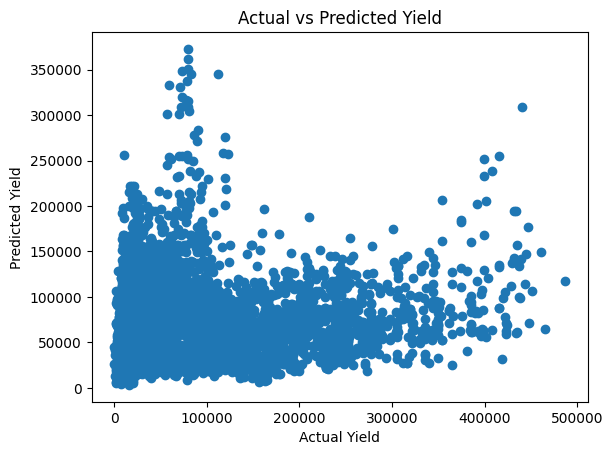

In [57]:
# ================== ACTUAL VS PREDICTED ==================
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.show()

In [58]:
# ================== ERROR METRIC ==================
print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 71062.62776895303


In [60]:
# ================== USER INPUT PREDICTION ==================
rain_val = float(input("Enter Rainfall: "))
temp_val = float(input("Enter Temperature: "))
pest_val = float(input("Enter Pesticides: "))

input_data = pd.DataFrame([[rain_val, temp_val, pest_val]],
                          columns=['Rainfall', 'Temperature', 'Pesticides'])

print("Predicted Yield:", rf_model.predict(input_data))

Enter Rainfall: 100
Enter Temperature: 30
Enter Pesticides: 15
Predicted Yield: [50479.1783433]


In [61]:
# ================== SAVE MODEL ==================
import joblib
joblib.dump(rf_model, "crop_model.pkl")

['crop_model.pkl']